# Single Parameter Frequentist Inference

*Leandro Mineti*

*Last edit: March 2020*

## Introduction

Suppose we have $Y_i$ independent and identically distributed random variables with distribution $Y_i \sim Normal (\mu, \sigma^2)$, we can define $y_i$ as instances from $Y_i$. On the inference problem, we have a sample of size $n: {y_1, y_2, ..., y_n}$, and want to make an inference about the value of mean $\mu$. There are many ways to approach this problem, on this notebook we will implement three different estimators for the mean:

- Sample mean estimator.
- Least squares estimator.
- Maximum likelihood estimator.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from IPython.core.pylabtools import figsize

np.random.seed(51)  # Set seed for reproducibility

real_mu = 5
real_sigma = 1
n = 1000

# Generate sample
sample_1 = real_sigma * np.random.randn(n) + real_mu

We generated a sample of size 1000 for $Y_i \sim Normal (5, 1)$. Let's take a look at our sample by looking at its histogram.

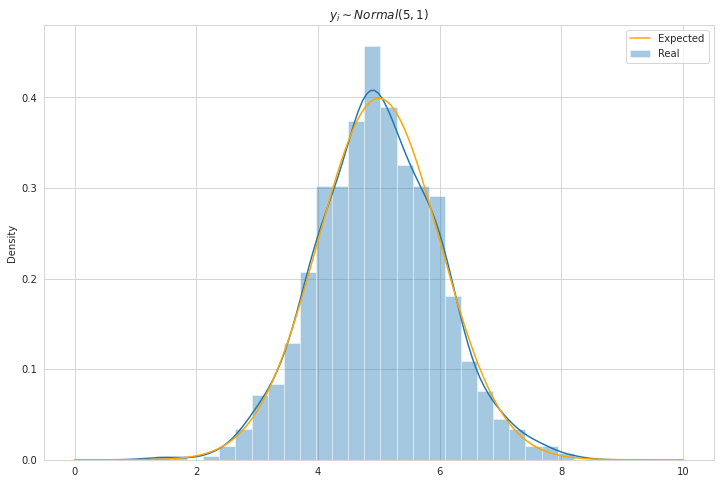

In [ ]:
#figsize(12, 8)

# Expected normal distribution
x = np.linspace(0,10,1000)
y = norm.pdf(x, loc=5, scale=1)

sns.set_style("whitegrid")
sns.distplot(sample_1, norm_hist = True)
plt.plot(x, y, color = 'orange')
plt.ylabel('Density')
plt.show();

## Estimators

Before exploring different examples of estimators, let's define what an estimator is. According to Casella and Berger [1], a point estimator is any function $W(X_1, ..., X_n)$ of a sample. Having that in mind, let's evaluate some different functions of the sample.

### Sample mean

We can define the sample mean as $\bar{y} = \frac{1}{n}\sum_{i=1}^{n}y_i$. Calculating the Expected Value of this equation, we have:

$$
\begin{align}
E(\bar{Y}) &= E(\frac{1}{n}\sum_{i=1}^{n}Y_i) = \frac{1}{n}E(\sum_{i=1}^{n}Y_i) \\
E(\bar{Y}) &= \frac{1}{n}\sum_{i=1}^{n}E(Y_i) = \frac{1}{n}\sum_{i=1}^{n}\mu \\
E(\bar{Y}) &= \frac{1}{n}n\mu \\
E(\bar{Y}) &= \mu
\end{align}
$$

Following a similar procedure for the Variance, we have:

$$
\begin{align}
V(\bar{Y}) &= V(\frac{1}{n}\sum_{i=1}^{n}Y_i) = \frac{1}{n^2}V(\sum_{i=1}^{n}Y_i) \\
V(\bar{Y}) &= \frac{1}{n^2}\sum_{i=1}^{n}V(Y_i) = \frac{1}{n^2}\sum_{i=1}^{n}\sigma^2 \\
V(\bar{Y}) &= \frac{1}{n^2}n\sigma^2 \\
V(\bar{Y}) &= \frac{\sigma^2}{n}
\end{align}
$$

From what we calculated, we expect the sample mean to be the real $\mu$. Let's calculate the sample mean:

In [ ]:
'The sample mean is {}.'.format(np.round(np.mean(sample_1), 5))

'The sample mean is 4.99545.'

#### Distribution

We expect the sample mean to have a distribution $\bar{Y} \sim Normal (\mu, \frac{\sigma^2}{n})$. For the data we generated: $\bar{Y} \sim Normal (5, \frac{1}{1000})$. We can check these distributions by generating a hundred samples with n = 1000 and assessing the results.

In [ ]:
# A hundred samples of size 1000
sample_100 = real_sigma * np.random.randn(100, n) + real_mu

# Calculate the mean for each sample
mean_100 = np.mean(sample_100, axis = 1)

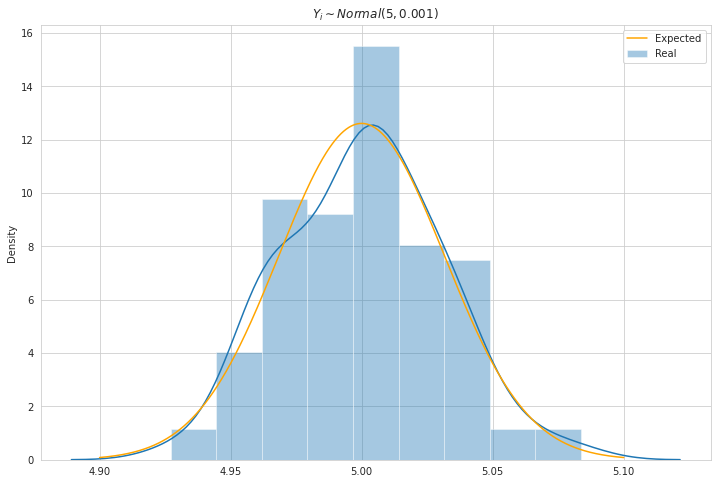

In [ ]:
# Expected normal distribution
x = np.linspace(4.9,5.1,1000)
y = norm.pdf(x, loc=5, scale = np.sqrt(0.001))

sns.distplot(mean_100, norm_hist = True);
plt.plot(x, y, color = 'orange')
plt.ylabel('Density')
plt.legend(('Expected', 'Real'), loc='upper right')
plt.title("$Y_i \sim Normal (5, 0.001)$")
plt.show();

### Least squares

Let's use a different representation for $Y_i \sim Normal (\mu, \sigma^2)$. Now we will see this distribution as the simplest regression problem: $Y_i = \beta_0 + \epsilon$, where $\epsilon \sim Normal(0, \sigma^2)$ and $\beta_0$ is a constant we want to identify. In this case, $\beta_0$ and $\mu$ are equivalent and the inference can be defined by the following optimization problem:

$$\hat{\beta_0} = \underset{\beta_0}{\text{argmin}} \sum_{i=1}^{n}(y_i - \beta_0)^2$$

We can solve this equation by calculating the derivative with respect to $\beta_0$ and setting it equal to zero:

$$
\begin{align}
\frac{\mathrm{d} \sum_{i=1}^{n}(y_i - \hat{\beta_0})^2}{\mathrm{d} \beta_0} &= 0 \\
\sum_{i=1}^{n}2(y_i - \hat{\beta_0}).(-1) &= 0 \\
-2\sum_{i=1}^{n}y_i + 2\sum_{i=1}^{n}\hat{\beta_0} &= 0 \\
2n\hat{\beta_0} &= 2\sum_{i=1}^{n}y_i \\
\hat{\beta_0} &= \frac{1}{n}\sum_{i=1}^{n}y_i
\end{align}
$$

We can see that this solution and the expected value for the sample mean are the same, $\hat{\beta_0} = \bar{y}$.

In [ ]:
from scipy.optimize import minimize

def squares(beta, sample):
  return (np.sum((sample - beta)**2))

beta0_hat = minimize(squares, 0, args = sample_1).x[0]

'The estimated beta_0 is {}.'.format(round(beta0_hat, 5))

'The estimated beta_0 is 4.99545.'

#### Distribution

Applying the same idea we used on the sample mean, let's check the distribution we get with the least squares estimator.

In [ ]:
least = [minimize(squares, 0, i).x for i in sample_100]

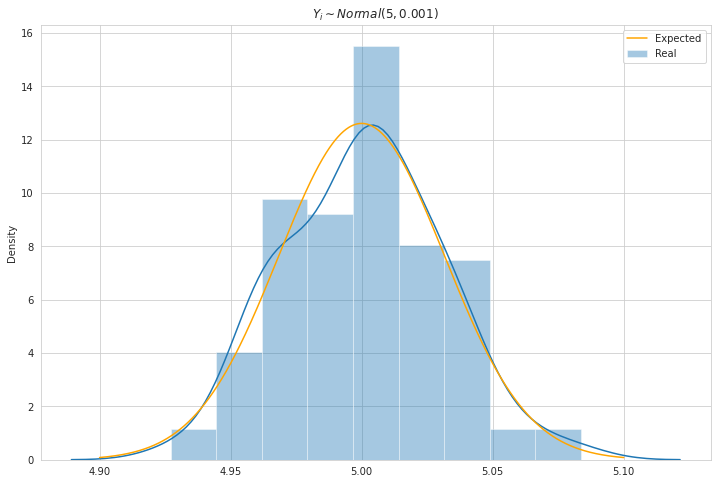

In [ ]:
sns.distplot(least)
plt.plot(x, y, color = 'orange')
plt.ylabel('Density')
plt.legend(('Expected', 'Real'), loc='upper right')
plt.title("$Y_i \sim Normal (5, 0.001)$")
plt.show();

### Maximum likelihood estimator

Before defining the optimization problem, we have to define the likelihood function. Assuming variables are **i.i.d** we can show that:

$$
\begin{align}
F(\beta_0, \sigma) &= P(Y_1 = y_1, Y_2 = y_2, ..., Y_n = y_n) \\
F(\beta_0, \sigma) &= P(Y_1 = y_1)\times P(Y_2 = y_2)\times ... \times P(Y_n = y_n) \\
F(\beta_0, \sigma) &= \prod_{i=1}^{n}P(Y_i = y_i) \\
F(\beta_0, \sigma) &= \prod_{i=1}^{n}\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{1}{2}(\frac{y_i-\beta_0}{\sigma})^2} \\
F(\beta_0, \sigma) &= (\frac{1}{\sqrt{2\pi}\sigma})^ne^{-\frac{1}{2}\frac{\sum_{i=1}^{n}(y_i-\beta_0)^2}{\sigma^2}} \\
log[F(\beta_0, \sigma)] &= -nlog(\sqrt{2\pi \sigma^2}) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \beta_0)^2
\end{align}
$$

Now we can find the $\beta_0$ that maximizes the function by defining the following optimization problem:

$$
\begin{align}
\frac{\partial log[F(\beta_0, \sigma)]}{\partial \beta_0} &= 0 \\
\frac{\partial }{\partial \beta_0} [-log(\sqrt{2\pi \sigma^2})-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \beta_0)^2] &= 0 \\
\frac{\partial }{\partial \beta_0} [-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \beta_0)^2] &= 0 \\
\frac{\partial }{\partial \beta_0} [-\sum_{i=1}^{n}(y_i - \beta_0)^2] &= 0 \\
-2\sum_{i=1}^{n}(y_i - \beta_0).(-1) &= 0 \\
2\sum_{i=1}^{n}y_i -2\sum_{i=1}^{n}\beta_0 &= 0 \\
-2n\beta_0 &= -2\sum_{i=1}^{n}y_i \\
\hat{\beta_0} &= \frac{1}{n}\sum_{i=1}^{n}y_i
\end{align}
$$

Again, we can see that this solution and the expected value for the sample mean are the same, $\hat{\beta_0} = \bar{y}$.

In [ ]:
from scipy.optimize import minimize

# Defined the loglikelihood with a positive sign to allow the use of 'minimize'
def log_likelihood(beta, sample):
  return n*np.log(np.sqrt(2*np.pi*(real_sigma**2)))+(np.sum((sample - beta)**2)/(2*(real_sigma**2)))

beta0_hat = minimize(log_likelihood, 0, args = sample_1).x[0]

'The estimated beta_0 is {}.'.format(round(beta0_hat, 5))

'The estimated beta_0 is 4.99545.'

#### Distribution

Again, let's check the distribution we get with the maximum likelihood estimator.

In [ ]:
mle = [minimize(log_likelihood, 0, i).x for i in sample_100]

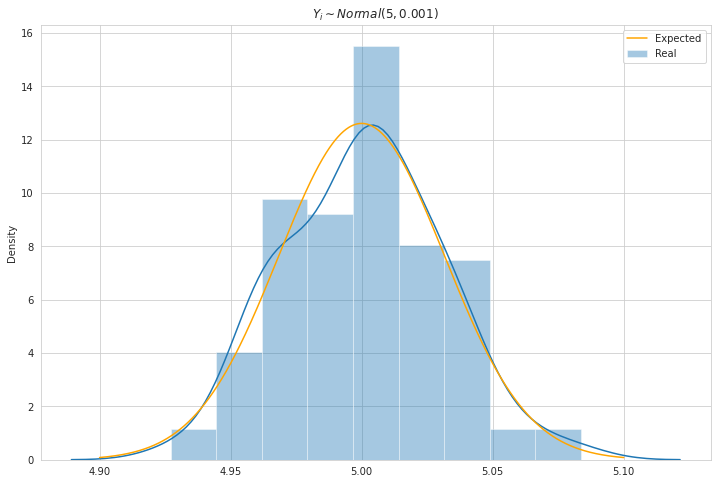

In [ ]:
sns.distplot(mle)
plt.plot(x, y, color = 'orange')
plt.ylabel('Density')
plt.legend(('Expected', 'Real'), loc='upper right')
plt.title("$Y_i \sim Normal (5, 0.001)$")
plt.show();

## Inference

### Reference range

As shown earlier, if the population follows a distribution $Y_i \sim Normal(\mu, \sigma^2)$ the sample mean follows $\bar{Y} \sim Normal(\mu, \frac{\sigma^2}{n})$. If we knew $\mu$ and $\sigma$, we could build a reference range for the possible values of sample mean.

$$RR(\bar{Y}, \alpha) : \mu \pm Z_{\alpha /2} \times \frac{\sigma}{\sqrt{n}}$$

### Confidence interval

When doing inference on a parameter we do not have access to its real value. We can build an interval around the sample mean, $\bar{Y}$, that probably encompasses the real $\mu$. This is known as the **confidence interval**.

$$CI(\mu, \alpha) : \bar{Y} \pm Z_{\alpha /2} \times \frac{\sigma}{\sqrt{n}}$$

Using the hundred samples we generated previously, we built a hundred confidence intervals with $Z_{\alpha /2} = 2$. When using specifying 2 standard deviations from the sample mean, we expect [around 95%](https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule) of the confidence intervals to contain the real $\mu$.

In [ ]:
mean_100 = np.mean(sample_100, axis = 1)

In [ ]:
# Build a confidence interval for each sample
ci_100 = [[x-2*1/np.sqrt(n), x+2*1/np.sqrt(n)] for x in mean_100]

# Checking if the confidence interval contains the real mu
ci_contains_mu = [(5 > x) & (5 < y) for x, y in ci_100]


'{} out of 11 confidence interval contained the real mu.'.format(np.sum(ci_contains_mu))

'97 out of 11 confidence interval contained the real mu.'

## References

[1] Casella, G., & Berger, R. L. (2002). Statistical inference (Vol. 2). Pacific Grove, CA: Duxbury.

[2] Costa, M. A. (2019). Tópicos em ciência dos dados: Introdução aos modelos paramétricos e seus aplicações utilizando o R. Bonecker.